In [23]:
# Clustering: Unsupervised because there is no Y target as such
#_________________________________________________________

# K-Means Clustering
# K-means clustering only works with Numeric Variables
# This is a distance-based algorithm
# Euclidean Distance Formula :
# Hence, categorical variables wouldn't be working here
# Feature Scaling is Mandatory | needed
# -----------------------------------------------------------------------
# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [24]:
# Importing the dataset
dataset = pd.read_csv('Mall_Customers.csv')

X = dataset.iloc[:, [3, 4]].values # Taking two columns into my study : Annual Income (k$) | Spending Score (1-100)
print(X)
dataset.head(2)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

,CustomerID,Gendre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81


In [25]:
dataset.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [26]:
dataset.isnull().sum()

CustomerID                0
Gendre                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

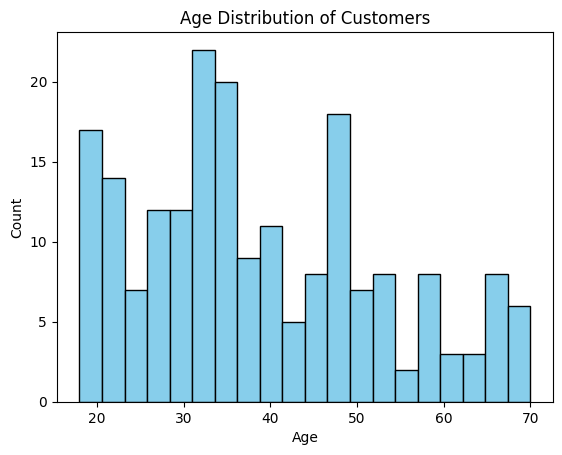

In [27]:
import matplotlib.pyplot as plt

plt.hist(dataset['Age'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution of Customers")
plt.show()

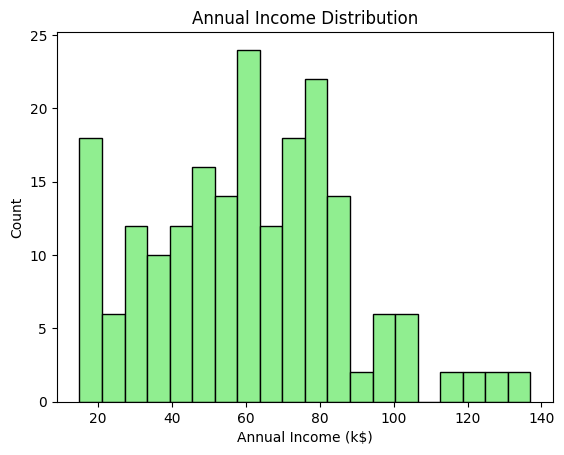

In [28]:
plt.hist(dataset['Annual Income (k$)'], bins=20, color='lightgreen', edgecolor='black')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")
plt.title("Annual Income Distribution")
plt.show()

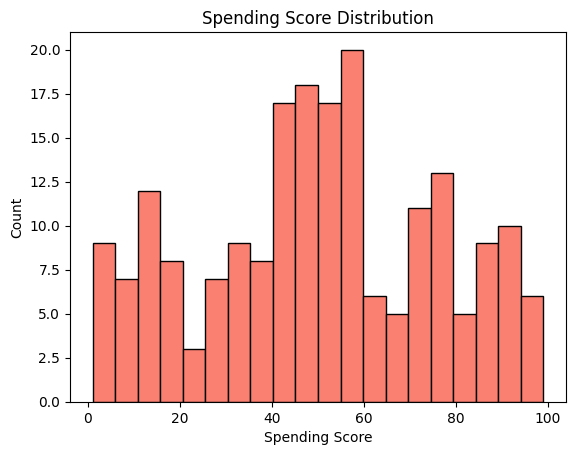

In [29]:
plt.hist(dataset['Spending Score (1-100)'], bins=20, color='salmon', edgecolor='black')
plt.xlabel("Spending Score")
plt.ylabel("Count")
plt.title("Spending Score Distribution")
plt.show()

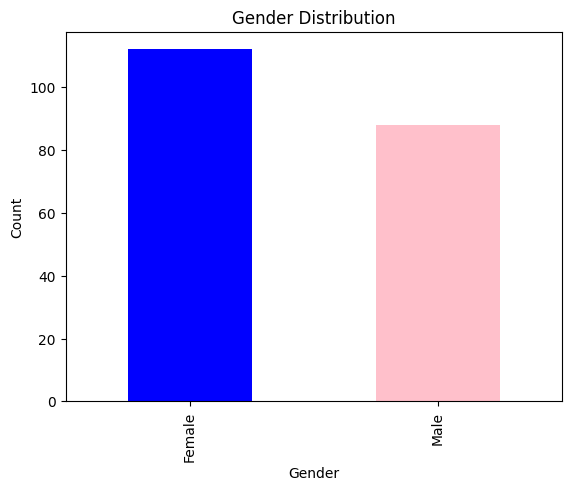

In [30]:
dataset['Gendre'].value_counts().plot(kind='bar', color=['blue','pink'])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

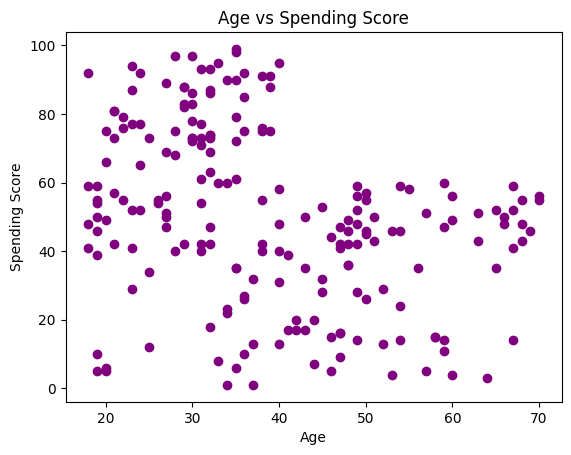

In [31]:
plt.scatter(dataset['Age'], dataset['Spending Score (1-100)'], color='purple')
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.title("Age vs Spending Score")
plt.show()

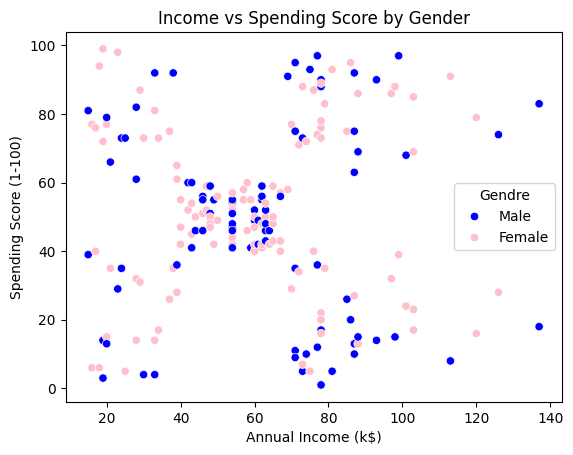

In [32]:
import seaborn as sns

sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Gendre', data=dataset, palette={'Male':'blue','Female':'pink'})
plt.title("Income vs Spending Score by Gender")
plt.show()

In [33]:
my_Cls = KMeans(n_clusters = 3, init = 'k-means++', random_state = 1234)

# here the value of n_clusters = 3 is K which means that you are willing to divide the samples into 3 clusters
# random_state need any integer number

# [K-Means++] is a smart centroid initialization technique >> May be just to improvise upon the time and calculations
#  and the rest of the algorithm is the same as that of K-Means.

In [34]:
my_Cls.fit(X) # applying the model on the data
my_Cls.inertia_
# Inertia actually calculates the sum of distances of all the points within a cluster from the centroid of that cluster. 
# Normally, we use Euclidean distance as the distance metric, as long as most of the features are numeric; otherwise, 
# Manhattan distance in cases where there are Outliers. Standard K-Means uses Euclidean distance, not Manhattan distance.

106348.37306211122

   CustomerID  Gendre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        2  
1        2  
2        2  
3        2  
4        2  
Cluster
2    123
1     39
0     38
Name: count, dtype: int64


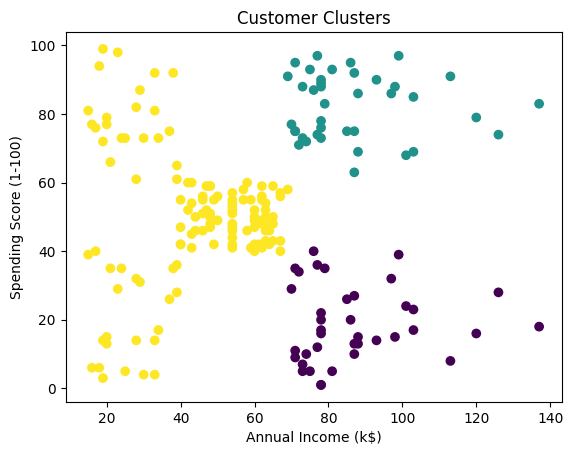

In [35]:
y_kmeans = my_Cls.fit_predict(X)
y_kmeans # below are the real clusters, and because indexing in Python starts from 0, you have 0 & 1 & 2 clusters

# Add cluster labels to DataFrame
dataset['Cluster'] = y_kmeans

# See first few records with cluster assignment
print(dataset.head())

# Check how many records per cluster
print(dataset['Cluster'].value_counts())

import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters")
plt.show()

Optimal K: 5


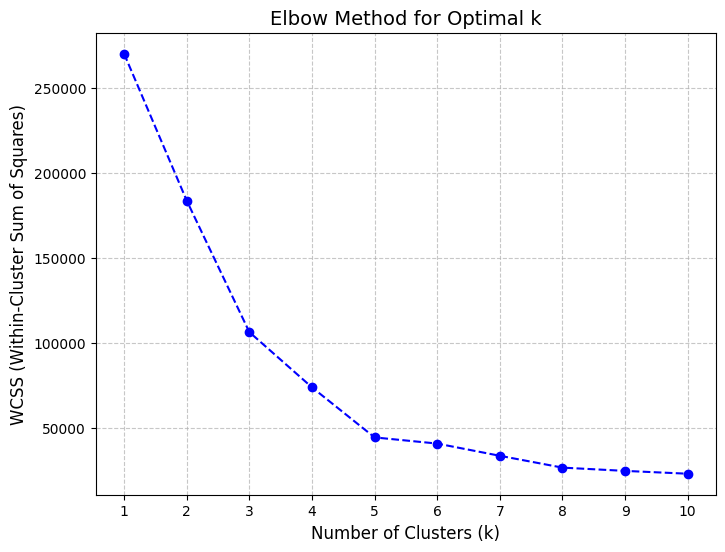

In [36]:
# Using the elbow method to find the optimal number of clusters
# How to know the relevant set of the groups | Clusters ?

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = [] # WCSS = Within-Cluster Sum of Squares also know as Intertia
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

# KneeLocator is a Python utility used to automatically find the "elbow point" in the Elbow Method graph.
# The elbow point helps determine the optimal number of clusters (K).
# Instead of visually guessing the elbow, KneeLocator detects it mathematically.
# Find elbow point using kneelocator

kneedle = KneeLocator(
    range(1, 11),
    wcss,
    curve='convex',
    direction='decreasing'
)
print("Optimal K:", kneedle.elbow)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

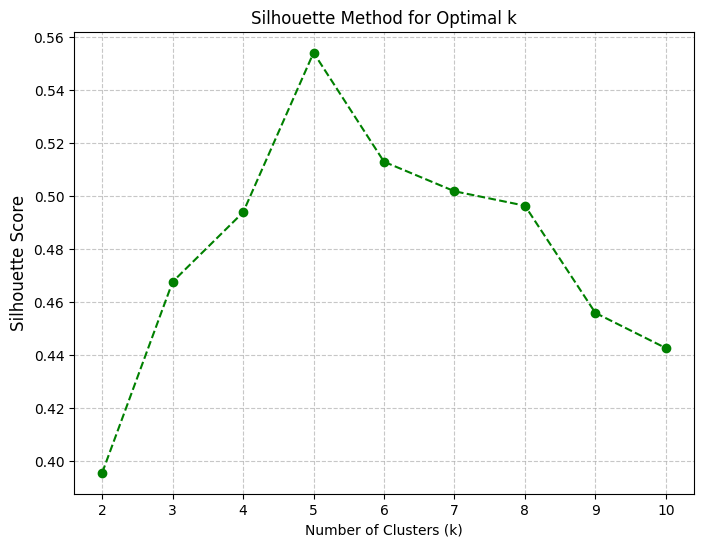

In [37]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

silhouette_scores = [] 
# silhouette_score is a metric used to evaluate the quality of clustering. 
# How well each data point fits into its assigned cluster compared to other clusters. −1 ≤ Silhouette Score ≤ 1

# Test k from 2 to 10 (silhouette is not defined for k=1)
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)   # X should be your scaled feature matrix
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o', linestyle='--', color='g')
plt.title('Silhouette Method for Optimal k', fontsize=12)
plt.xlabel('Number of Clusters (k)', fontsize=10)
plt.ylabel('Silhouette Score', fontsize=12)
plt.xticks(range(2, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

   CustomerID  Gendre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64


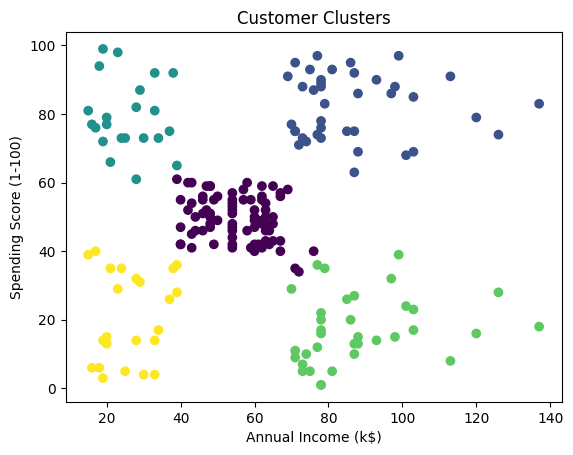

In [38]:
# BASED ON THE ABOVE CHART : I CAN INTERPRET THAT 5 IS THE OPTIMAL NUBMER OF CLUSTER
# HENCE RUNNING MY CLUSTERING MODEL WITH 5 CLUSTERS NOW

# Fitting K-Means to the dataset
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)
y_kmeans

# Add cluster labels to DataFrame
dataset['Cluster'] = y_kmeans

# See first few records with cluster assignment
print(dataset.head())

# Check how many records per cluster
print(dataset['Cluster'].value_counts())

import matplotlib.pyplot as plt

plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Clusters")
plt.show()

In [39]:
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

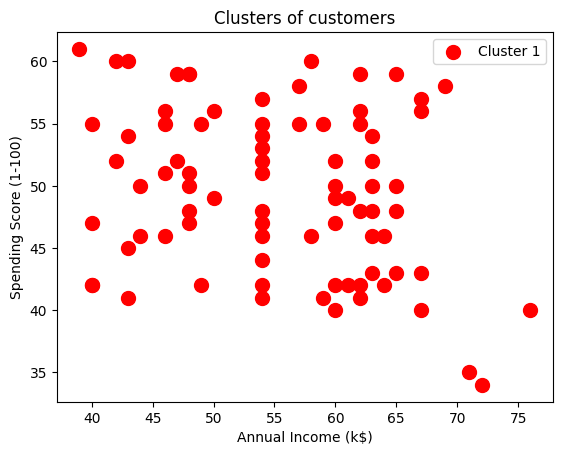

In [40]:
# Visualising the clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')

# 1st Cluster with Annual income(0) on X axis >>   X[y_kmeans == 0, 0]
# 1st Cluster with Spending Scode(1) on Y axis >>  X[y_kmeans == 0, 1]

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

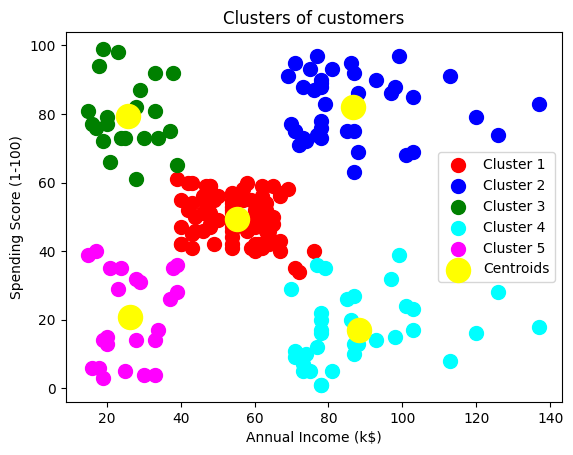

In [41]:
# Visualising the clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')

plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [42]:
# K‑Means clustering on your Customer_Churn.csv dataset using the features MonthlyCharges and TotalCharges. 
# This will help segment customers based on their billing patterns.

import pandas as pd

# Load dataset
df = pd.read_csv("Customer_Churn.csv")

# Convert TotalCharges to numeric (handle blanks)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["MonthlyCharges", "TotalCharges"])

# Select features
X = df[["MonthlyCharges", "TotalCharges"]].values

In [43]:
from sklearn.cluster import KMeans

# Fit KMeans with 3 clusters (example)
kmeans = KMeans(n_clusters=3, init="k-means++", random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Add cluster labels to DataFrame
df["Cluster"] = y_kmeans

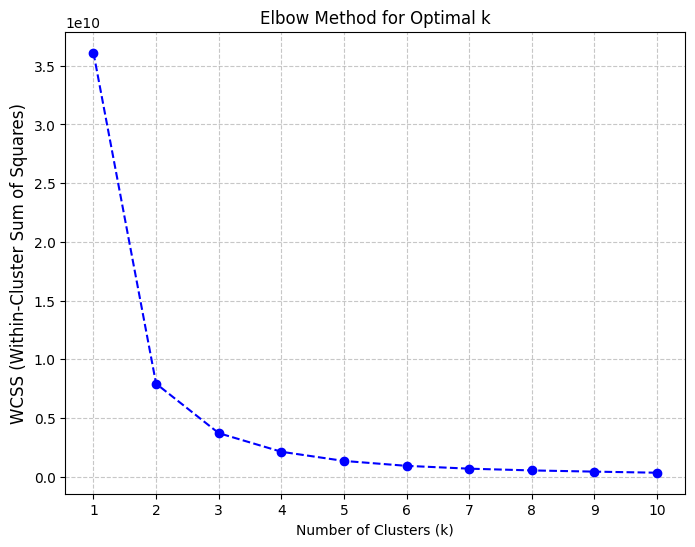

In [44]:
# Using the elbow method to find the optimal number of clusters
# How to know the relevant set of the groups | Clusters ?

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal k', fontsize=12)
plt.xlabel('Number of Clusters (k)', fontsize=10)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

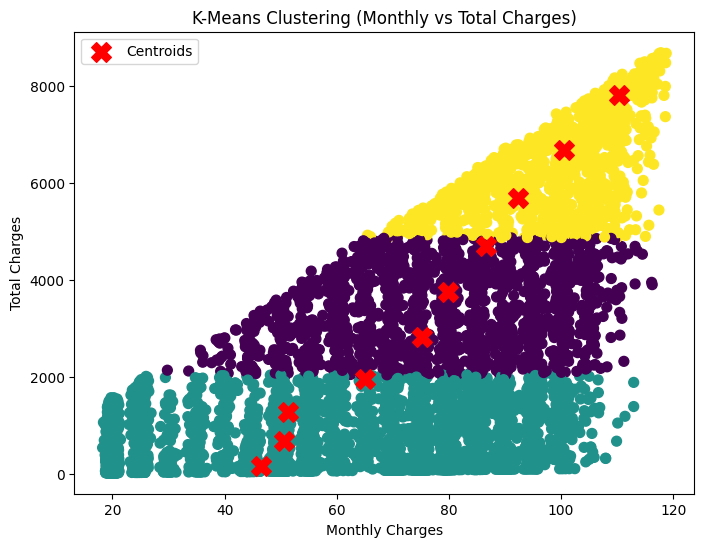

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

# Scatter plot with cluster colors
plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap="viridis", s=50)

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:,0], 
            kmeans.cluster_centers_[:,1], 
            s=200, c="red", marker="X", label="Centroids")

plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("K-Means Clustering (Monthly vs Total Charges)")
plt.legend()
plt.show()

   CustomerID  Gendre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


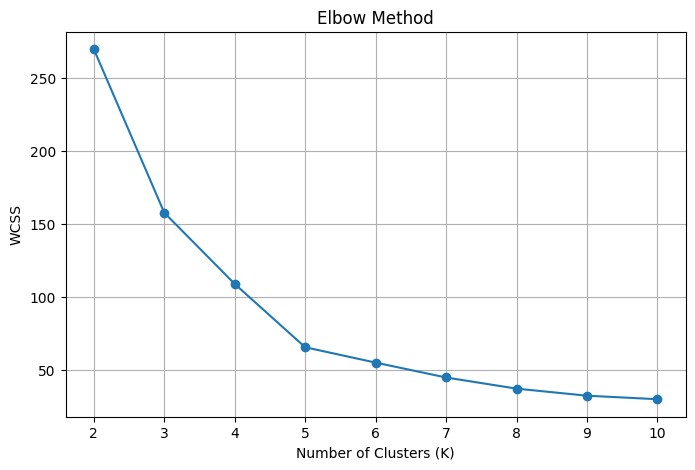

Silhouette Score: 0.555
Dunn Index: 0.059


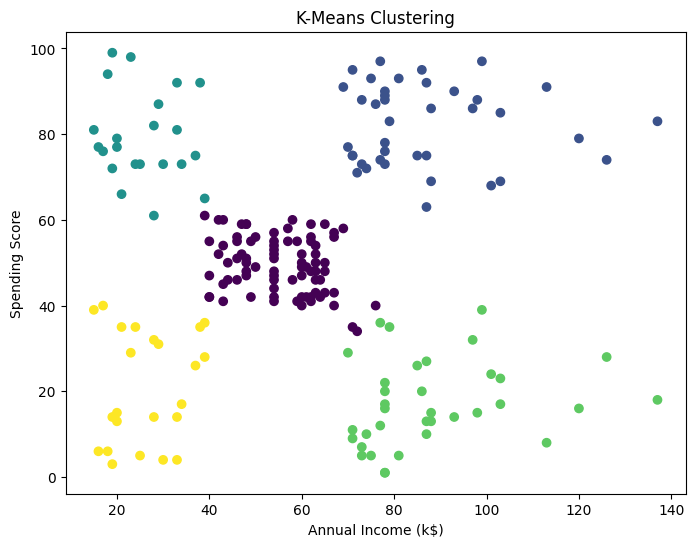

In [46]:
# ==========================
# Import Libraries
# ==========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist

# ==========================
# Load Dataset
# ==========================
df = pd.read_csv("Mall_Customers.csv")

print(df.head())

# ==========================
# Select Features
# ==========================
# Using Annual Income and Spending Score

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

# ==========================
# Feature Scaling
# ==========================
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ==========================
# Elbow Method
# ==========================
wcss = []

K = range(2,11)

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    wcss.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8,5))

plt.plot(K, wcss, marker='o')

plt.xlabel('Number of Clusters (K)')

plt.ylabel('WCSS')

plt.title('Elbow Method')

plt.grid(True)

plt.show()

# ==========================
# Choose Optimal K
# ==========================
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

labels = kmeans.fit_predict(X_scaled)

# ==========================
# Silhouette Score
# ==========================
sil_score = silhouette_score(
    X_scaled,
    labels
)

print("Silhouette Score:", round(sil_score,3))

# ==========================
# Dunn Index Function
# ==========================
def dunn_index(X, labels):

    unique_clusters = np.unique(labels)

    # Minimum inter-cluster distance
    inter_cluster = []

    for i in unique_clusters:

        for j in unique_clusters:

            if i < j:

                cluster_i = X[labels == i]

                cluster_j = X[labels == j]

                distances = cdist(
                    cluster_i,
                    cluster_j
                )

                inter_cluster.append(
                    np.min(distances)
                )

    min_inter = np.min(inter_cluster)

    # Maximum intra-cluster diameter
    intra_cluster = []

    for i in unique_clusters:

        cluster = X[labels == i]

        if len(cluster) > 1:

            distances = cdist(
                cluster,
                cluster
            )

            intra_cluster.append(
                np.max(distances)
            )

    max_intra = np.max(intra_cluster)

    return min_inter / max_intra

# ==========================
# Dunn Score
# ==========================
dunn_score = dunn_index(
    X_scaled,
    labels
)

print("Dunn Index:", round(dunn_score,3))

# ==========================
# Visualize Clusters
# ==========================
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=labels
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('K-Means Clustering')
plt.show()